In [2]:
!pip install -q condacolab
import condacolab
# Workaround issue with Python 3.12:
# condacolab.install()
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [ ]:
!mamba install -q graph-tool

warning  libmamba [xorg-xorgproto-2025.1-hb03c661_0] The following files were already present in the environment:
    - include/X11/extensions/EVI.h
    - include/X11/extensions/EVIproto.h
    - include/X11/extensions/ag.h
    - include/X11/extensions/agproto.h
    - include/X11/extensions/cup.h
    - include/X11/extensions/cupproto.h
    - include/X11/extensions/dbe.h
    - include/X11/extensions/dbeproto.h
    - include/X11/extensions/dpmsconst.h
    - include/X11/extensions/dpmsproto.h
    - include/X11/extensions/ge.h
    - include/X11/extensions/geproto.h
    - include/X11/extensions/lbx.h
    - include/X11/extensions/lbxproto.h
    - include/X11/extensions/mitmiscconst.h
    - include/X11/extensions/mitmiscproto.h
    - include/X11/extensions/multibufconst.h
    - include/X11/extensions/multibufproto.h
    - include/X11/extensions/secur.h
    - include/X11/extensions/securproto.h
    - include/X11/extensions/shapeconst.h
    - include/X11/extensions/shapeproto.h
    - include/X11

In [ ]:
!mamba install -q scipy

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MO412_Project_v2/soc-sign-bitcoinotc.csv')
df

,source,target,rating,time
0,6,2,4,1.289242e+09
1,6,5,2,1.289242e+09
2,1,15,1,1.289243e+09
3,4,3,7,1.289245e+09
4,13,16,8,1.289254e+09
...,...,...,...,...
35587,4499,1810,1,1.453612e+09
35588,2731,3901,5,1.453679e+09
35589,2731,4897,5,1.453679e+09
35590,13,1128,1,1.453680e+09


In [ ]:
ts = pd.to_datetime(df.iloc[:, 3], unit='s')

start_date = ts.min()
end_date = ts.max()

year = ts.dt.year

counts_per_year = year.groupby(year).size()
print(counts_per_year)


time
2010      142
2011     7758
2012     9432
2013    12982
2014     4225
2015     1011
2016       42
Name: time, dtype: int64


In [ ]:
G_otc = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr=True, create_using=nx.DiGraph())

G_otc_plus = G_otc.edge_subgraph([(u, v) for u, v, d in G_otc.edges(data=True) if d['rating'] > 0]).copy()

G_otc_minus = G_otc.edge_subgraph([(u, v) for u, v, d in G_otc.edges(data=True) if d['rating'] < 0]).copy()


In [ ]:
N_otc = G_otc.number_of_nodes()
L_otc = G_otc.number_of_edges()

N_otc_plus = G_otc_plus.number_of_nodes()
L_otc_plus = G_otc_plus.number_of_edges()

N_otc_minus = G_otc_minus.number_of_nodes()
L_otc_minus = G_otc_minus.number_of_edges()

print("Number of nodes:", N_otc, N_otc_plus, N_otc_minus)
print("Number of edges:", L_otc, L_otc_plus, L_otc_minus)

Number of nodes: 5881 5573 1606
Number of edges: 35592 32029 3563


In [ ]:
density = nx.density(G_otc)
reciprocity = nx.reciprocity(G_otc)

density_plus = nx.density(G_otc_plus)
reciprocity_plus = nx.reciprocity(G_otc_plus)

density_minus = nx.density(G_otc_minus)
reciprocity_minus = nx.reciprocity(G_otc_minus)

print("Densities:", density, density_plus, density_minus)
print("Reciprocities:", reciprocity, reciprocity_plus,reciprocity_minus )


Densities: 0.0010292571373048454 0.0010314382401355937 0.0013822775184956723
Reciprocities: 0.7923128792987189 0.8391145524368541 0.17064271681167556


In [ ]:
k_in  = [d for _, d in G_otc.in_degree()]
k_out = [d for _, d in G_otc.out_degree()]

k_in_plus  = [d for _, d in G_otc_plus.in_degree()]
k_out_plus = [d for _, d in G_otc_plus.out_degree()]

k_in_minus  = [d for _, d in G_otc_minus.in_degree()]
k_out_minus = [d for _, d in G_otc_minus.out_degree()]

In [ ]:
k_in_counter = Counter(k_in)
pk_in = {k: v / N_otc for k, v in k_in_counter.items()}
k_out_counter = Counter(k_out)
pk_out = {k: v / N_otc for k, v in k_out_counter.items()}
k_in_vals = np.array(sorted(pk_in.keys()))
pk_in_vals = np.array([pk_in[k] for k in k_in_vals])
k_out_vals = np.array(sorted(pk_out.keys()))
pk_out_vals = np.array([pk_out[k] for k in k_out_vals])

k_in_plus_counter = Counter(k_in_plus)
pk_in_plus = {k: v / N_otc_plus for k, v in k_in_plus_counter.items()}
k_out_plus_counter = Counter(k_out_plus)
pk_out_plus = {k: v / N_otc_plus for k, v in k_out_plus_counter.items()}
k_in_vals_plus = np.array(sorted(pk_in_plus.keys()))
pk_in_vals_plus = np.array([pk_in_plus[k] for k in k_in_vals_plus])
k_out_vals_plus = np.array(sorted(pk_out_plus.keys()))
pk_out_vals_plus = np.array([pk_out_plus[k] for k in k_out_vals_plus])

k_in_minus_counter = Counter(k_in_minus)
pk_in_minus = {k: v / N_otc_minus for k, v in k_in_minus_counter.items()}
k_out_minus_counter = Counter(k_out_minus)
pk_out_minus = {k: v / N_otc_minus for k, v in k_out_minus_counter.items()}
k_in_vals_minus = np.array(sorted(pk_in_minus.keys()))
pk_in_vals_minus = np.array([pk_in_minus[k] for k in k_in_vals_minus])
k_out_vals_minus = np.array(sorted(pk_out_minus.keys()))
pk_out_vals_minus = np.array([pk_out_minus[k] for k in k_out_vals_minus])

#print(pk_out)

In [ ]:
avg_k = sum(dict(G_otc.in_degree()).values()) / G_otc.number_of_nodes()

avg_k_plus = sum(dict(G_otc_plus.in_degree()).values()) / G_otc_plus.number_of_nodes()

avg_k_minus = sum(dict(G_otc_minus.in_degree()).values()) / G_otc_minus.number_of_nodes()

print(avg_k, avg_k_plus, avg_k_minus)

6.052031967352491 5.7471738740355285 2.2185554171855544


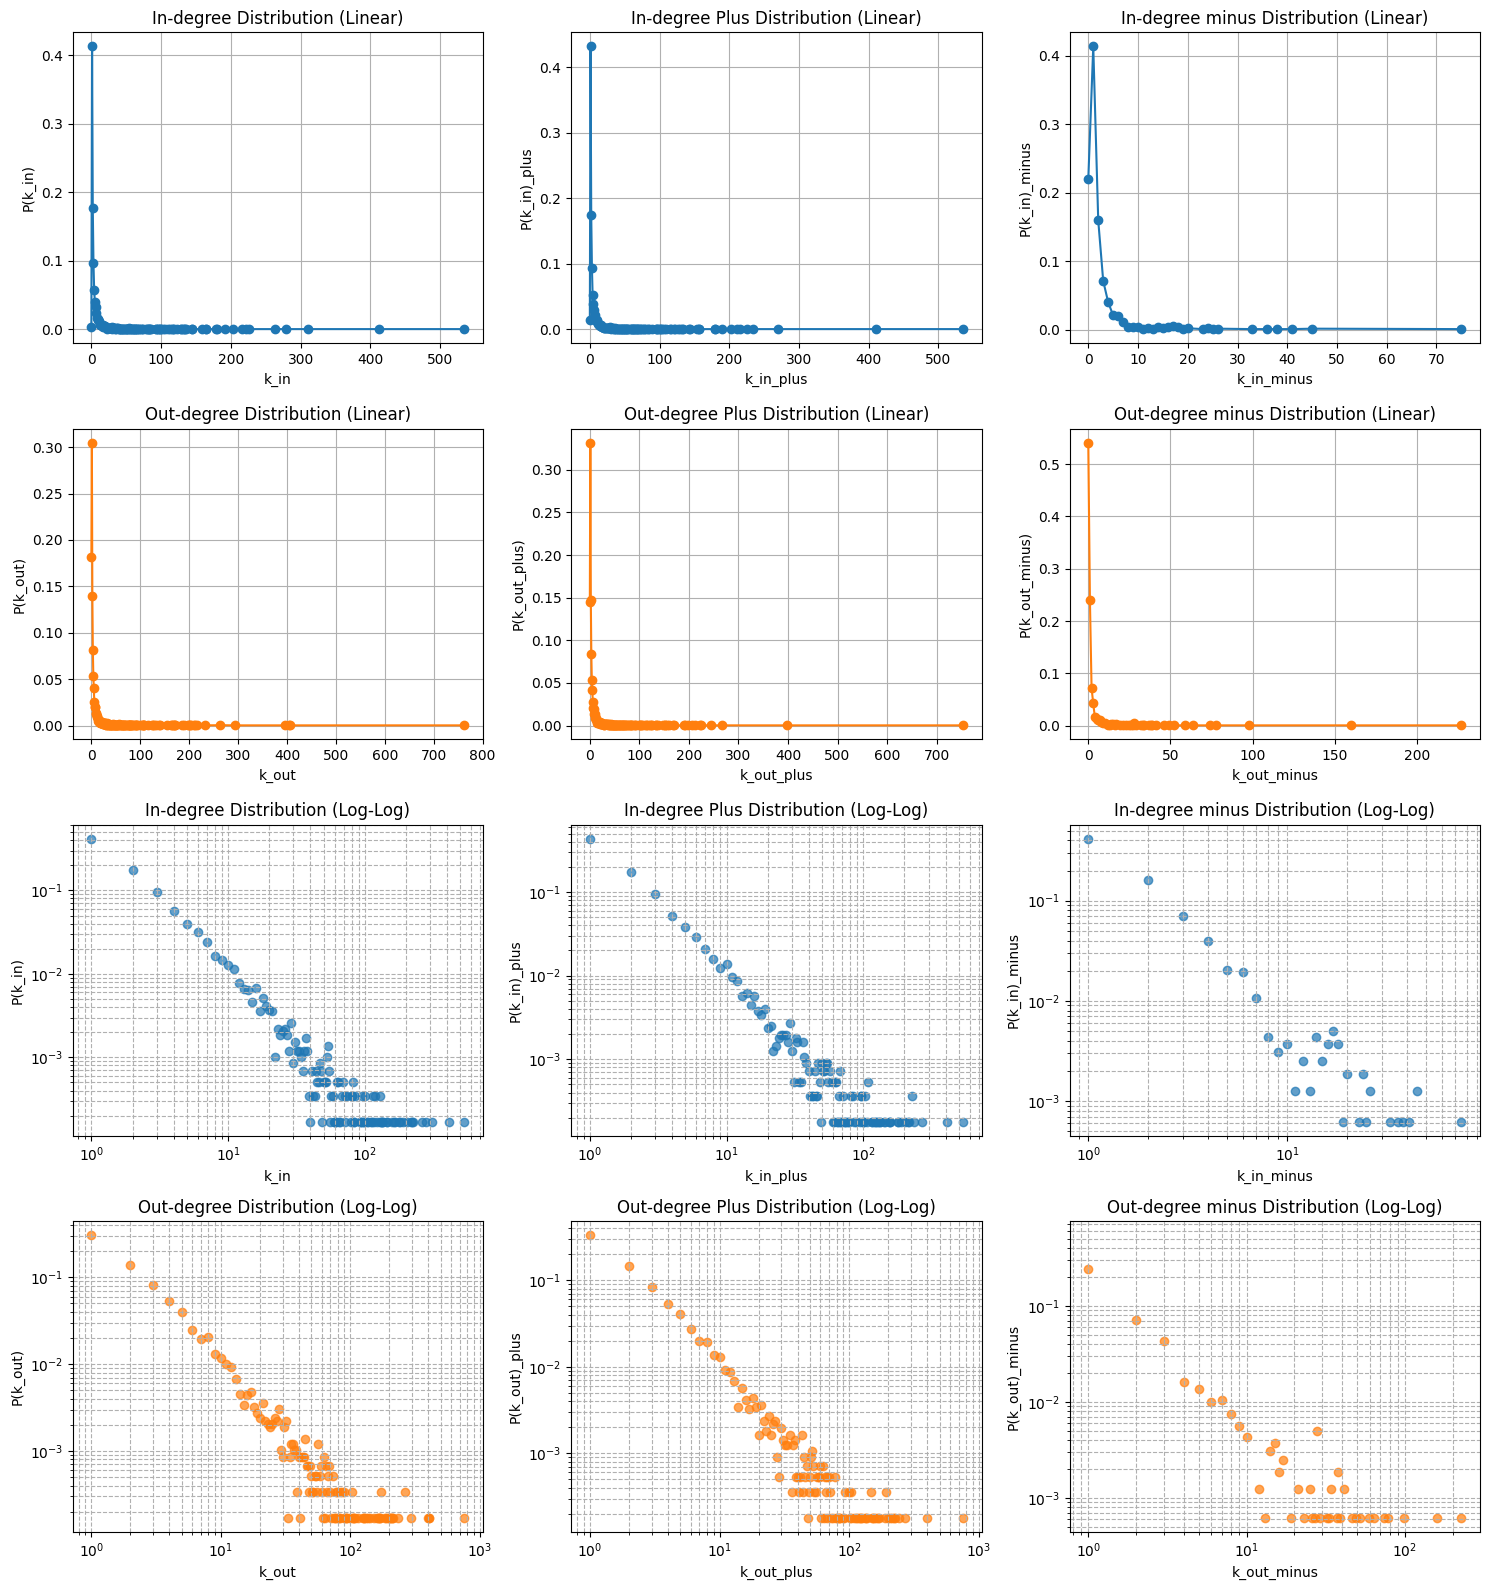

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

axes[0, 0].plot(k_in_vals, pk_in_vals, 'o-', color='tab:blue')
axes[0, 0].set_title('In-degree Distribution (Linear)')
axes[0, 0].set_xlabel('k_in')
axes[0, 0].set_ylabel('P(k_in)')
axes[0, 0].grid(True)

axes[1, 0].plot(k_out_vals, pk_out_vals, 'o-', color='tab:orange')
axes[1, 0].set_title('Out-degree Distribution (Linear)')
axes[1, 0].set_xlabel('k_out')
axes[1, 0].set_ylabel('P(k_out)')
axes[1, 0].grid(True)

axes[2, 0].scatter(k_in_vals, pk_in_vals, alpha=0.7, color='tab:blue')
axes[2, 0].set_xscale('log')
axes[2, 0].set_yscale('log')
axes[2, 0].set_title('In-degree Distribution (Log-Log)')
axes[2, 0].set_xlabel('k_in')
axes[2, 0].set_ylabel('P(k_in)')
axes[2, 0].grid(True, which='both', ls='--')

axes[3, 0].scatter(k_out_vals, pk_out_vals, alpha=0.7, color='tab:orange')
axes[3, 0].set_xscale('log')
axes[3, 0].set_yscale('log')
axes[3, 0].set_title('Out-degree Distribution (Log-Log)')
axes[3, 0].set_xlabel('k_out')
axes[3, 0].set_ylabel('P(k_out)')
axes[3, 0].grid(True, which='both', ls='--')

#plus
axes[0, 1].plot(k_in_vals_plus, pk_in_vals_plus, 'o-', color='tab:blue')
axes[0, 1].set_title('In-degree Plus Distribution (Linear)')
axes[0, 1].set_xlabel('k_in_plus')
axes[0, 1].set_ylabel('P(k_in)_plus')
axes[0, 1].grid(True)

axes[1, 1].plot(k_out_vals_plus, pk_out_vals_plus, 'o-', color='tab:orange')
axes[1, 1].set_title('Out-degree Plus Distribution (Linear)')
axes[1, 1].set_xlabel('k_out_plus')
axes[1, 1].set_ylabel('P(k_out_plus)')
axes[1, 1].grid(True)

axes[2, 1].scatter(k_in_vals_plus, pk_in_vals_plus, alpha=0.7, color='tab:blue')
axes[2, 1].set_xscale('log')
axes[2, 1].set_yscale('log')
axes[2, 1].set_title('In-degree Plus Distribution (Log-Log)')
axes[2, 1].set_xlabel('k_in_plus')
axes[2, 1].set_ylabel('P(k_in)_plus')
axes[2, 1].grid(True, which='both', ls='--')

axes[3, 1].scatter(k_out_vals_plus, pk_out_vals_plus, alpha=0.7, color='tab:orange')
axes[3, 1].set_xscale('log')
axes[3, 1].set_yscale('log')
axes[3, 1].set_title('Out-degree Plus Distribution (Log-Log)')
axes[3, 1].set_xlabel('k_out_plus')
axes[3, 1].set_ylabel('P(k_out)_plus')
axes[3, 1].grid(True, which='both', ls='--')

#minus
axes[0, 2].plot(k_in_vals_minus, pk_in_vals_minus, 'o-', color='tab:blue')
axes[0, 2].set_title('In-degree minus Distribution (Linear)')
axes[0, 2].set_xlabel('k_in_minus')
axes[0, 2].set_ylabel('P(k_in)_minus')
axes[0, 2].grid(True)

axes[1, 2].plot(k_out_vals_minus, pk_out_vals_minus, 'o-', color='tab:orange')
axes[1, 2].set_title('Out-degree minus Distribution (Linear)')
axes[1, 2].set_xlabel('k_out_minus')
axes[1, 2].set_ylabel('P(k_out_minus)')
axes[1, 2].grid(True)

axes[2, 2].scatter(k_in_vals_minus, pk_in_vals_minus, alpha=0.7, color='tab:blue')
axes[2, 2].set_xscale('log')
axes[2, 2].set_yscale('log')
axes[2, 2].set_title('In-degree minus Distribution (Log-Log)')
axes[2, 2].set_xlabel('k_in_minus')
axes[2, 2].set_ylabel('P(k_in)_minus')
axes[2, 2].grid(True, which='both', ls='--')

axes[3, 2].scatter(k_out_vals_minus, pk_out_vals_minus, alpha=0.7, color='tab:orange')
axes[3, 2].set_xscale('log')
axes[3, 2].set_yscale('log')
axes[3, 2].set_title('Out-degree minus Distribution (Log-Log)')
axes[3, 2].set_xlabel('k_out_minus')
axes[3, 2].set_ylabel('P(k_out)_minus')
axes[3, 2].grid(True, which='both', ls='--')

#plt.savefig(f"plot.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
wccs = list(nx.weakly_connected_components(G_otc))
largest_wcc = max(wccs, key=len)

print(f"WCC (qtd): {len(wccs)}")
print(f"Largest WCC: {len(largest_wcc)} nodes ({100*len(largest_wcc)/N_otc:.1f}%)")
print()


WCC (qtd): 4
Largest WCC: 5875 nodes (99.9%)



In [ ]:
wccs_plus = list(nx.weakly_connected_components(G_otc_plus))
largest_wcc_plus = max(wccs_plus, key=len)

print(f"WCC (qtd): {len(wccs_plus)}")
print(f"Largest WCC: {len(largest_wcc_plus)} nodes ({100*len(largest_wcc_plus)/N_otc_plus:.1f}%)")
print()

WCC (qtd): 9
Largest WCC: 5551 nodes (99.6%)



In [ ]:
wccs_minus = list(nx.weakly_connected_components(G_otc_minus))
largest_wcc_minus = max(wccs_minus, key=len)

print(f"WCC (qtd): {len(wccs_minus)}")
print(f"Largest WCC: {len(largest_wcc_minus)} nodes ({100*len(largest_wcc_minus)/N_otc_minus:.1f}%)")
print()

WCC (qtd): 69
Largest WCC: 1455 nodes (90.6%)



In [ ]:
sccs = list(nx.strongly_connected_components(G_otc))
largest_scc = max(sccs, key=len)

print(f"SCC (qtd): {len(sccs)}")
print(f"Largest SCC: {len(largest_scc)} nodes ({100*len(largest_scc)/N_otc:.1f}%)")

SCC (qtd): 1144
Largest SCC: 4709 nodes (80.1%)


In [ ]:
sccs_plus = list(nx.strongly_connected_components(G_otc_plus))
largest_scc_plus = max(sccs_plus, key=len)

print(f"SCC (qtd): {len(sccs_plus)}")
print(f"Largest SCC: {len(largest_scc_plus)} nodes ({100*len(largest_scc_plus)/N_otc_plus:.1f}%)")

SCC (qtd): 956
Largest SCC: 4568 nodes (82.0%)


In [ ]:
sccs_minus = list(nx.strongly_connected_components(G_otc_minus))
largest_scc_minus = max(sccs_minus, key=len)

print(f"SCC (qtd): {len(sccs_minus)}")
print(f"Largest SCC: {len(largest_scc_minus)} nodes ({100*len(largest_scc_minus)/N_otc_minus:.1f}%)")

SCC (qtd): 1318
Largest SCC: 251 nodes (15.6%)


In [ ]:
G_otc_und = G_otc.subgraph(largest_wcc).to_undirected()
avg_C = nx.average_clustering(G_otc_und)
print(f"Clustering Coefficient: {avg_C:.6f}")

Clustering Coefficient: 0.177686


In [ ]:
G_otc_und_plus = G_otc_plus.subgraph(largest_wcc_plus).to_undirected()
avg_C_plus = nx.average_clustering(G_otc_und_plus)
print(f"Clustering Coefficient: {avg_C_plus:.6f}")

Clustering Coefficient: 0.163827


In [ ]:
G_otc_und_minus = G_otc_minus.subgraph(largest_wcc_minus).to_undirected()
avg_C_minus = nx.average_clustering(G_otc_und_minus)
print(f"Clustering Coefficient: {avg_C_minus:.6f}")

Clustering Coefficient: 0.034118


In [ ]:
scc_nodes = set(largest_scc)

G_rev = G_otc.reverse()
reachable_to_scc = set()
for node in scc_nodes:
    reachable_to_scc |= nx.descendants(G_rev, node)
in_component = reachable_to_scc - scc_nodes

reachable_from_scc = set()
for node in scc_nodes:
    reachable_from_scc |= nx.descendants(G_otc, node)
out_component = reachable_from_scc - scc_nodes

wcc_nodes = set(max(nx.weakly_connected_components(G_otc), key=len))
tendrils = wcc_nodes - scc_nodes - in_component - out_component

print(f"SCC: {len(scc_nodes):,} nodes ({100*len(scc_nodes)/N_otc:.1f}%)")
print(f"IN: {len(in_component):,} nodes ({100*len(in_component)/N_otc:.1f}%)")
print(f"OUT: {len(out_component):,} nodes ({100*len(out_component)/N_otc:.1f}%)")
print(f"Tendrils: {len(tendrils):,} nodes ({100*len(tendrils)/N_otc:.1f}%)")
print(f"Isolated: {N_otc - len(wcc_nodes):,} nodes ({100*(N_otc-len(wcc_nodes))/N_otc:.1f}%)")

SCC: 4,709 nodes (80.1%)
IN: 25 nodes (0.4%)
OUT: 1,140 nodes (19.4%)
Tendrils: 1 nodes (0.0%)
Isolated: 6 nodes (0.1%)


In [ ]:
scc_nodes_plus = set(largest_scc_plus)

G_rev_plus = G_otc_plus.reverse()
reachable_to_scc_plus = set()
for node in scc_nodes_plus:
    reachable_to_scc_plus |= nx.descendants(G_rev_plus, node)
in_component_plus = reachable_to_scc_plus - scc_nodes_plus

reachable_from_scc_plus = set()
for node in scc_nodes_plus:
    reachable_from_scc_plus |= nx.descendants(G_otc_plus, node)
out_component_plus = reachable_from_scc_plus - scc_nodes_plus

wcc_nodes_plus = set(max(nx.weakly_connected_components(G_otc_plus), key=len))
tendrils_plus = wcc_nodes_plus - scc_nodes_plus - in_component_plus - out_component_plus

print(f"SCC: {len(scc_nodes_plus):,} nodes ({100*len(scc_nodes_plus)/N_otc_plus:.1f}%)")
print(f"IN: {len(in_component_plus):,} nodes ({100*len(in_component_plus)/N_otc_plus:.1f}%)")
print(f"OUT: {len(out_component_plus):,} nodes ({100*len(out_component_plus)/N_otc_plus:.1f}%)")
print(f"Tendrils: {len(tendrils_plus):,} nodes ({100*len(tendrils_plus)/N_otc_plus:.1f}%)")
print(f"Isolated: {N_otc_plus - len(wcc_nodes_plus):,} nodes ({100*(N_otc_plus-len(wcc_nodes_plus))/N_otc_plus:.1f}%)")

SCC: 4,568 nodes (82.0%)
IN: 88 nodes (1.6%)
OUT: 863 nodes (15.5%)
Tendrils: 32 nodes (0.6%)
Isolated: 22 nodes (0.4%)


In [ ]:
scc_nodes_minus = set(largest_scc_minus)

G_rev_minus = G_otc_minus.reverse()
reachable_to_scc_minus = set()
for node in scc_nodes_minus:
    reachable_to_scc_minus |= nx.descendants(G_rev_minus, node)
in_component_minus = reachable_to_scc_minus - scc_nodes_minus

reachable_from_scc_minus = set()
for node in scc_nodes_minus:
    reachable_from_scc_minus |= nx.descendants(G_otc_minus, node)
out_component_minus = reachable_from_scc_minus - scc_nodes_minus

wcc_nodes_minus = set(max(nx.weakly_connected_components(G_otc_minus), key=len))
tendrils_minus = wcc_nodes_minus - scc_nodes_minus - in_component_minus - out_component_minus

print(f"SCC: {len(scc_nodes_minus):,} nodes ({100*len(scc_nodes_minus)/N_otc_minus:.1f}%)")
print(f"IN: {len(in_component_minus):,} nodes ({100*len(in_component_minus)/N_otc_minus:.1f}%)")
print(f"OUT: {len(out_component_minus):,} nodes ({100*len(out_component_minus)/N_otc_minus:.1f}%)")
print(f"Tendrils: {len(tendrils_minus):,} nodes ({100*len(tendrils_minus)/N_otc_minus:.1f}%)")
print(f"Isolated: {N_otc_minus - len(wcc_nodes_minus):,} nodes ({100*(N_otc_minus-len(wcc_nodes_minus))/N_otc_minus:.1f}%)")

SCC: 251 nodes (15.6%)
IN: 120 nodes (7.5%)
OUT: 647 nodes (40.3%)
Tendrils: 437 nodes (27.2%)
Isolated: 151 nodes (9.4%)


In [ ]:
nx.write_gexf(G_otc,'/content/drive/MyDrive/MO412_Project_v2/otc_full.gexf')

In [ ]:
nx.write_gexf(G_otc_plus,'/content/drive/MyDrive/MO412_Project_v2/otc_plus.gexf')

In [ ]:
nx.write_gexf(G_otc_minus,'/content/drive/MyDrive/MO412_Project_v2/otc_minus.gexf')

In [ ]:
g_minus = Graph(directed=True)
v_map = {}

def get_v(n):
    if n not in v_map:
        v_map[n] = g_minus.add_vertex()
    return v_map[n]

for u, v in G_otc_minus.edges():
    g_minus.add_edge(get_v(u), get_v(v))

pos = sfdp_layout(g_minus)

graph_draw(
    g_minus,
    pos=pos,
    vertex_size=5,
    edge_pen_width=0.5
)


NameError: name 'Graph' is not defined

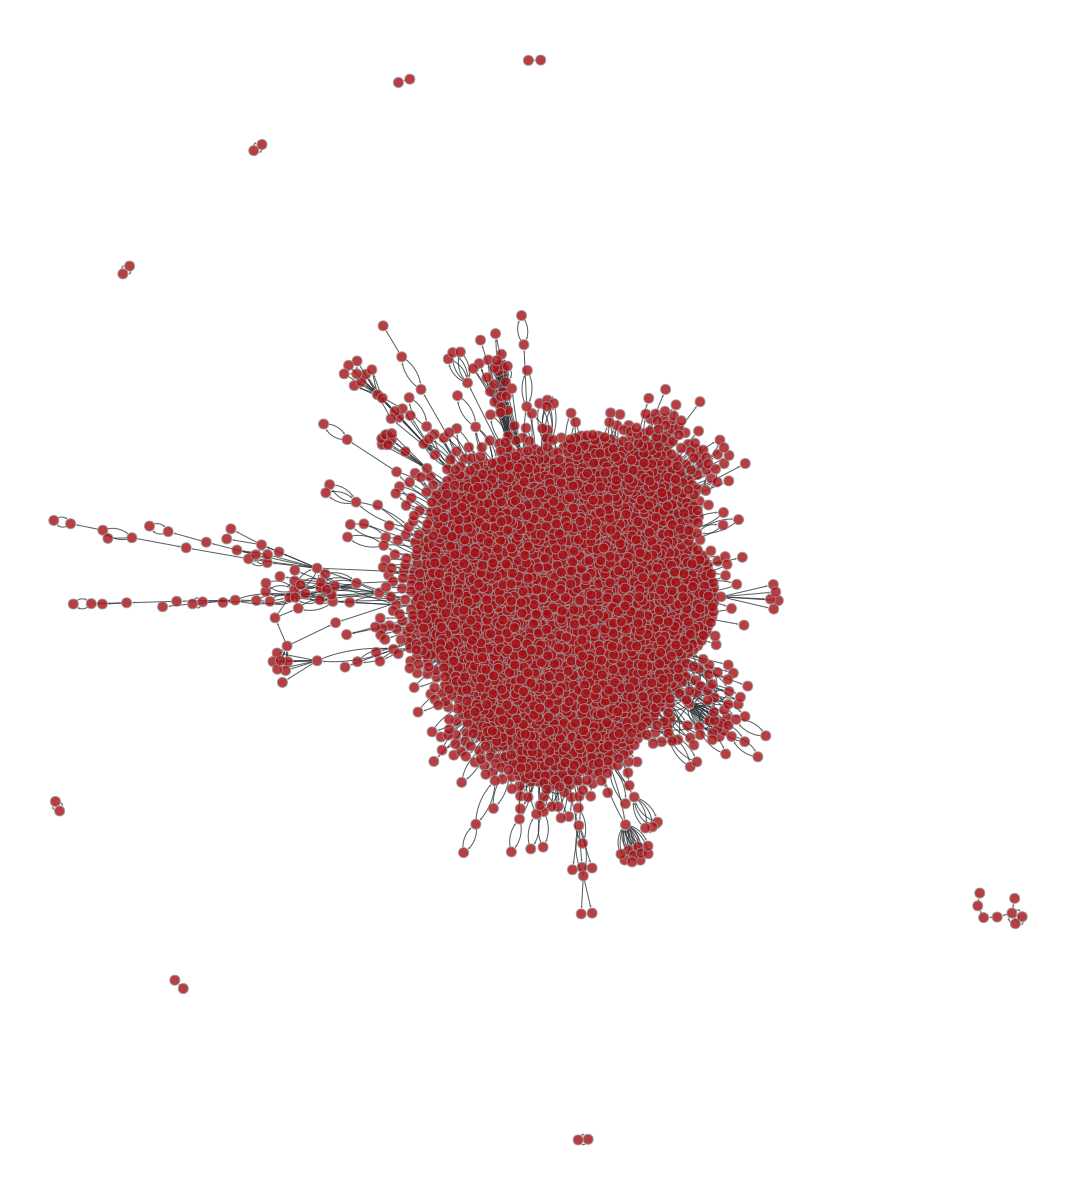

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7ce5c3c41850, at 0x7ce5c4bc98e0>

In [ ]:
g_plus = Graph(directed=True)
v_map = {}

def get_v(n):
    if n not in v_map:
        v_map[n] = g_plus.add_vertex()
    return v_map[n]

for u, v in G_otc_plus.edges():
    g_plus.add_edge(get_v(u), get_v(v))

pos = sfdp_layout(g_plus)

graph_draw(
    g_plus,
    pos=pos,
    vertex_size=5,
    edge_pen_width=0.5
)

In [ ]:
g = Graph(directed=True)
v_map = {}

def get_v(n):
    if n not in v_map:
        v_map[n] = g.add_vertex()
    return v_map[n]

for u, v in G_otc.edges():
    g.add_edge(get_v(u), get_v(v))

pos = sfdp_layout(g)

graph_draw(
    g,
    pos=pos,
    vertex_size=5,
    edge_pen_width=0.5
)

NameError: name 'Graph' is not defined

In [ ]:
e_time = g.new_edge_property("int64_t")
e_weight = g.new_edge_property("double")


for _, row in df.iterrows():
    u = get_v(row['source'])
    v = get_v(row['target'])
    e = g.add_edge(u, v)

    e_time[e] = row['time']

    # opcional
    if 'rating' in df.columns:
        e_weight[e] = row['rating']


g.ep['time'] = e_time
g.ep['weight'] = e_weight


NameError: name 'g' is not defined

In [ ]:
pos = sfdp_layout(g)

In [ ]:
t_min = df['time'].min()
t_max = df['time'].max()
efilt = g.new_edge_property("bool")


def apply_time_filter(T):
    for e in g.edges():
        efilt[e] = (g.ep.time[e] <= T)
    g.set_edge_filter(efilt)

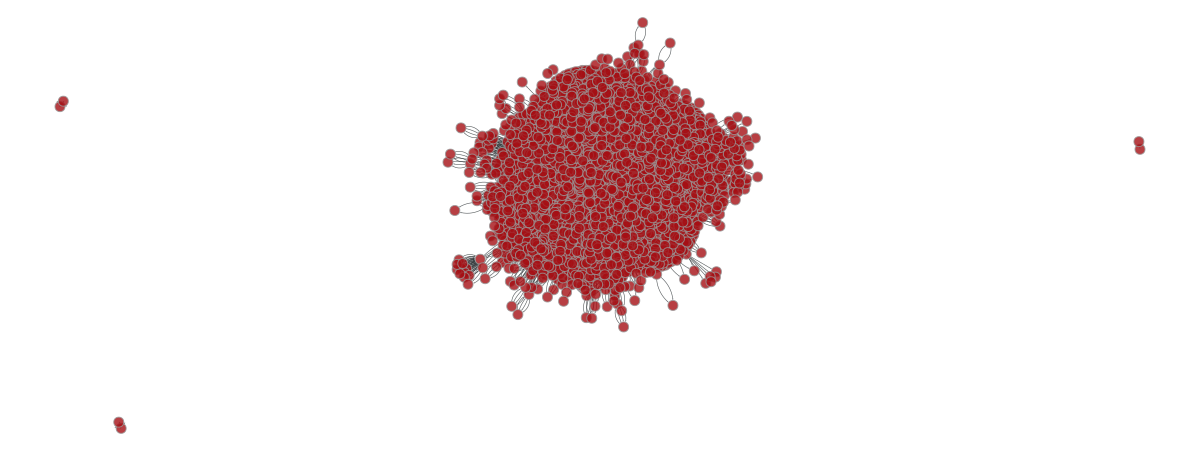

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7ce5b4588830, at 0x7ce5c3be7530>

In [ ]:
apply_time_filter(t_min + (t_max - t_min) // 2)

graph_draw(
    g,
    pos=pos,
    vertex_size=5,
    edge_pen_width=0.3
)

In [ ]:
e_year = g.new_edge_property("int")

for e, y in zip(g.edges(), year):
    e_year[e] = int(y)

g.ep['year'] = e_year

#e_year[e] = year
#frames = np.linspace(t_min, t_max, 100).astype(int)

In [ ]:

efilt = g.new_edge_property("bool")

def apply_year(Y):
    for e in g.edges():
        efilt[e] = (g.ep.year[e] <= Y)
    g.set_edge_filter(efilt)


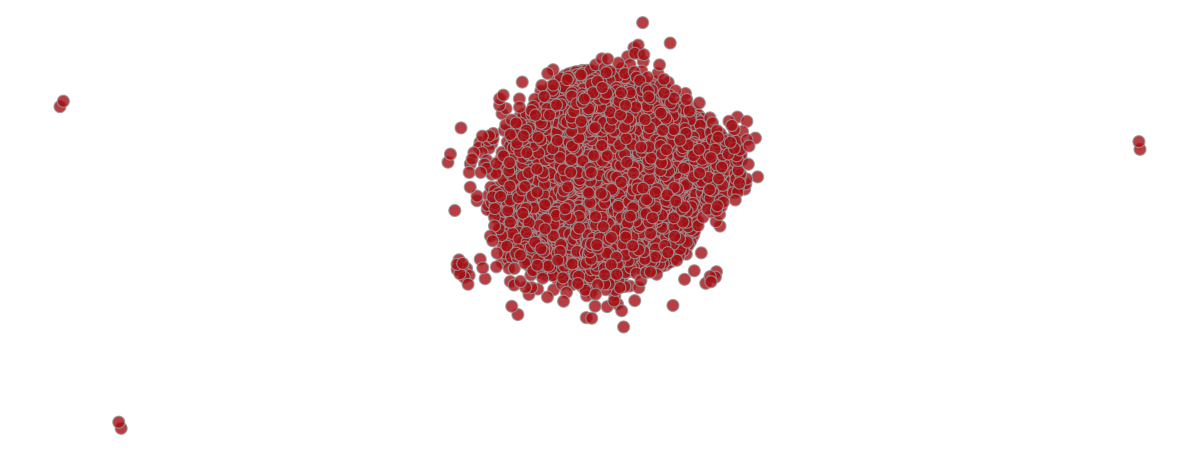

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7ce5b4588830, at 0x7ce5a7dcf9e0>

In [ ]:
apply_year(2013)

graph_draw(
    g,
    pos=pos,
    vertex_size=6,
    edge_pen_width=0.4
)


In [ ]:
from graph_tool.draw import graph_draw

for i, T in enumerate(frames):
    apply_time_filter(T)

    graph_draw(
        g,
        pos=pos,
        vertex_size=5,
        edge_pen_width=0.3,
        output=f"frame_{i:03d}.png"
    )


In [ ]:
!ffmpeg -framerate 10 -i frame_%03d.png evolution.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!ffmpeg -framerate 10 -i frame_%03d.png evolution.gif

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:

def count_edges_up_to(T):
    return sum(1 for e in g.edges() if g.ep.time[e] <= T)

for T in frames[:10]:
    print(T, count_edges_up_to(T))


1289241911 35593
1290902946 35593
1292563980 35593
1294225015 35593
1295886049 35593
1297547084 35593
1299208118 35593
1300869152 35593
1302530187 35593
1304191221 35593
